In [1]:
# import os
# import sys
# sys.path.insert(1, os.path.abspath(os.path.join('..', 'src')))

import jax

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

# AGOP of max margin classifiers with symmetric gaussian data

The observations are a result of the symmetry. However, in this linear case, any translation or shear of the data points would result in the same transformation on the Bayes predictor. The AGOP would then have a left and right factor of this transformation. The SVD of this transformation would determine the scaling and trasnformation of the eigenvalues/eigenvectors of the AGOP.

In [2]:
key = jax.random.key(33)

n = 100
d = 2

In [3]:
mu0 = jnp.array([-d*jnp.sqrt(d), -d*jnp.sqrt(d)])
mu1 = jnp.array([d*jnp.sqrt(d), d*jnp.sqrt(d)])

Sigma0 = jnp.eye(d)
Sigma1 = jnp.eye(d)

In [4]:
key0, key1 = jr.split(key, 2)
X0 = jr.multivariate_normal(key0, mu0, Sigma0, shape=(n//2,))
X1 = jr.multivariate_normal(key1, mu1, Sigma1, shape=(n//2,))

In [5]:
X = jnp.vstack([X0, X1])
y = jnp.array([-1]*(n//2) + [1]*(n//2))

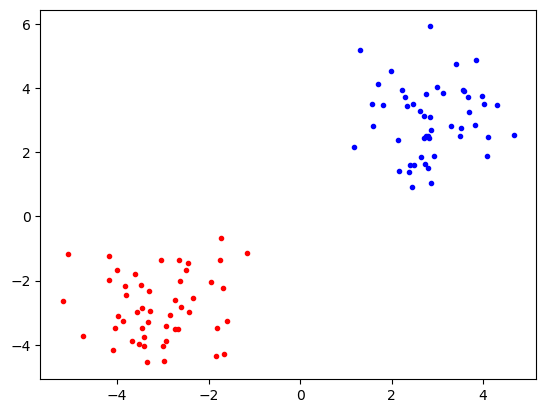

In [6]:
plt.plot(X[:n//2][:, 0], X[:n//2][:, 1], 'r.')
plt.plot(X[n//2:][:, 0], X[n//2:][:, 1], 'b.')

## LDA classifier

For Gaussina data satisfying homoscedacity, the Bayes optimal predictor is the linear discriminant analysis (LDA) classifier. This is based off (log)likelihood ratios (i.e. it is hypothesis testing).

The equations are $$\begin{aligned} w &= \Sigma^{-1}(\mu_1 - \mu_0) \\ b &= \frac12 w^T(\mu_0 + \mu_1) \end{aligned}$$

In [7]:
w = jnp.linalg.inv(Sigma1) @ (mu1 - mu0)
b = -0.5 * w.T @ (mu0 + mu1)

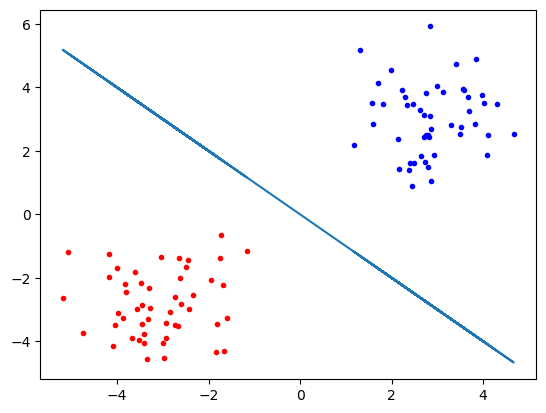

In [8]:
plt.plot(X[:n//2][:, 0], X[:n//2][:, 1], 'r.')
plt.plot(X[n//2:][:, 0], X[n//2:][:, 1], 'b.')
plt.plot(X[:, 0], - (w[0]/w[1]) * X[:, 0] - (b/w[1]))

In [9]:
w_shift = jnp.array([w[0] - 0.5, w[1] + 0.5])
w_scale = jnp.array([jnp.sqrt(d)*w[0], w[1]])

In [10]:
bayes_margin = min(y * (X @ w + b) / jnp.linalg.norm(w))
shift_margin = min(y * (X @ w_shift + b) / jnp.linalg.norm(w_shift))
scale_margin = min(y * (X @ w_scale + b) / jnp.linalg.norm(w_scale))

In [11]:
bayes_margin, shift_margin, scale_margin

(Array(1.635634, dtype=float32),
 Array(1.6225874, dtype=float32),
 Array(1.6153857, dtype=float32))

In [12]:
bayes_agop =  jnp.outer(w, w)
shift_agop =  jnp.outer(w_shift, w_shift)
scale_agop =  jnp.outer(w_scale, w_scale)

In [13]:
bayes_agop, shift_agop, scale_agop

(Array([[31.999998, 31.999998],
        [31.999998, 31.999998]], dtype=float32),
 Array([[26.593145, 31.749998],
        [31.749998, 37.906853]], dtype=float32),
 Array([[63.999992, 45.25483 ],
        [45.25483 , 31.999998]], dtype=float32))

In [ ]:
bayes_eigenvals, bayes_eigenvecs = jnp.linalg.eig(bayes_agop)
shift_eigenvals, shift_eigenvecs = jnp.linalg.eig(shift_agop)
scale_eigenvals, scale_eigenvecs = jnp.linalg.eig(scale_agop)

In [26]:
w / jnp.linalg.norm(w), w_shift / jnp.linalg.norm(w_shift), w_scale / jnp.linalg.norm(w_scale)

(Array([0.7071068, 0.7071068], dtype=float32),
 Array([0.64210343, 0.766618  ], dtype=float32),
 Array([0.8164966, 0.5773503], dtype=float32))

In [15]:
bayes_eigenvals, bayes_eigenvecs, shift_eigenvals, shift_eigenvecs, scale_eigenvals, scale_eigenvecs

(Array([63.999996+0.j,  0.      +0.j], dtype=complex64),
 Array([[ 0.70710677+0.j, -0.70710677+0.j],
        [ 0.70710677+0.j,  0.70710677+0.j]], dtype=complex64),
 Array([3.8146973e-06+0.j, 6.4500000e+01+0.j], dtype=complex64),
 Array([[-0.766618 +0.j, -0.6421035+0.j],
        [ 0.6421035+0.j, -0.766618 +0.j]], dtype=complex64),
 Array([9.599999e+01+0.j, 1.885363e-06+0.j], dtype=complex64),
 Array([[ 0.81649655+0.j, -0.57735026+0.j],
        [ 0.57735026+0.j,  0.81649655+0.j]], dtype=complex64))

## Trace norm of AGOP as optimality

It appears that the Bayes optimal solution minimizes the trace norm of the AGOP: $$f^* = \argmin_{f \ \text{measurable}} \| \operatorname{AGOP}{(f)} \|_* = \argmin_{f \ \text{measurable}} \sum_{i = 1}^{\min{\{m, n\}}} \sigma_i(\operatorname{AGOP}{(f)})$$

Possible question: can we prove this? Are there cases where Bayes optimality is measured by the more general Schatten $p$-norm?

In [22]:
sum(jnp.sqrt(bayes_eigenvals)).real, sum(jnp.sqrt(shift_eigenvals)).real, sum(jnp.sqrt(scale_eigenvals).real)

(Array(7.9999995, dtype=float32),
 Array(8.033142, dtype=float32),
 Array(9.799332, dtype=float32))

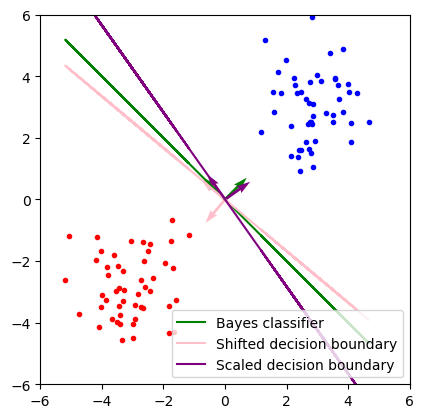

In [31]:
plt.plot(X[:n//2][:, 0], X[:n//2][:, 1], 'r.', label='_nolegend_')
plt.plot(X[n//2:][:, 0], X[n//2:][:, 1], 'b.', label='_nolegend_')

plt.plot(X[:, 0], - (w[0]/w[1]) * X[:, 0] - (b/w[1]), 'g')
plt.plot(X[:, 0], - (w_shift[0]/w_shift[1]) * X[:, 0] - (b/w_shift[1]), 'pink')
plt.plot(X[:, 0], - (w_scale[0]/w_scale[1]) * X[:, 0] - (b/w_scale[1]), 'purple')

plt.quiver(0, 0, bayes_eigenvecs[0][0], bayes_eigenvecs[1][0], angles='xy', scale_units='xy', scale=1, color='g', label='_nolegend_')
plt.quiver(0, 0, bayes_eigenvecs[0][1], bayes_eigenvecs[1][1], angles='xy', scale_units='xy', scale=1, color='g', label='_nolegend_')

plt.quiver(0, 0, shift_eigenvecs[0][0], shift_eigenvecs[1][0], angles='xy', scale_units='xy', scale=1, color='pink', label='_nolegend_')
plt.quiver(0, 0, shift_eigenvecs[0][1], shift_eigenvecs[1][1], angles='xy', scale_units='xy', scale=1, color='pink', label='_nolegend_')

plt.quiver(0, 0, scale_eigenvecs[0][0], scale_eigenvecs[1][0], angles='xy', scale_units='xy', scale=1, color='purple', label='_nolegend_')
plt.quiver(0, 0, scale_eigenvecs[0][1], scale_eigenvecs[1][1], angles='xy', scale_units='xy', scale=1, color='purple', label='_nolegend_')

plt.legend(['Bayes classifier', 'Shifted decision boundary', 'Scaled decision boundary'], loc='lower right')

plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.gca().set_aspect('equal', adjustable='box')

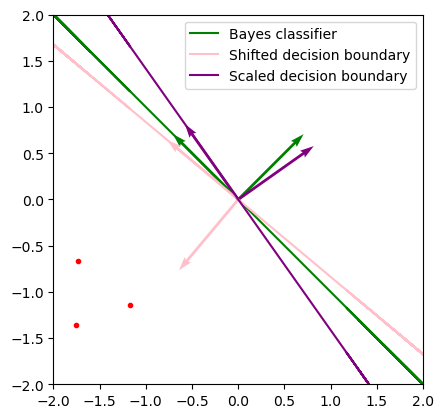

In [30]:
plt.plot(X[:n//2][:, 0], X[:n//2][:, 1], 'r.', label='_nolegend_')
plt.plot(X[n//2:][:, 0], X[n//2:][:, 1], 'b.', label='_nolegend_')

plt.plot(X[:, 0], - (w[0]/w[1]) * X[:, 0] - (b/w[1]), 'g')
plt.plot(X[:, 0], - (w_shift[0]/w_shift[1]) * X[:, 0] - (b/w_shift[1]), 'pink')
plt.plot(X[:, 0], - (w_scale[0]/w_scale[1]) * X[:, 0] - (b/w_scale[1]), 'purple')

plt.quiver(0, 0, bayes_eigenvecs[0][0], bayes_eigenvecs[1][0], angles='xy', scale_units='xy', scale=1, color='g', label='_nolegend_')
plt.quiver(0, 0, bayes_eigenvecs[0][1], bayes_eigenvecs[1][1], angles='xy', scale_units='xy', scale=1, color='g', label='_nolegend_')

plt.quiver(0, 0, shift_eigenvecs[0][0], shift_eigenvecs[1][0], angles='xy', scale_units='xy', scale=1, color='pink', label='_nolegend_')
plt.quiver(0, 0, shift_eigenvecs[0][1], shift_eigenvecs[1][1], angles='xy', scale_units='xy', scale=1, color='pink', label='_nolegend_')

plt.quiver(0, 0, scale_eigenvecs[0][0], scale_eigenvecs[1][0], angles='xy', scale_units='xy', scale=1, color='purple', label='_nolegend_')
plt.quiver(0, 0, scale_eigenvecs[0][1], scale_eigenvecs[1][1], angles='xy', scale_units='xy', scale=1, color='purple', label='_nolegend_')

plt.legend(['Bayes classifier', 'Shifted decision boundary', 'Scaled decision boundary'], loc='upper right')

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal', adjustable='box')